# D07 · Efficiency belongs to a contrast

<!-- paper-first -->
### Begin with the paper question

**Read or revisit [PD06](../../curriculum/papers/design.md#pd06), [PD01](../../curriculum/papers/design.md#pd01).** Use the assigned first-pass sections in the guide; if you already read them, return only to the relevant figure or claim. Do this before the technical explanation below.

**Motivation:** How does a fixed scanning budget provide different information for different contrasts?

Write a two-sentence prediction and one thing you cannot yet explain. Ask your AI tutor to locate evidence in the supplied paper and distinguish it from inference. A paper link motivates this question; it does not mean the paper uses every method demonstrated here.

**After the experiment:** revisit your prediction in the [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md). Explain one mechanism you now understand, cite a result from this notebook, and name a paper claim this exercise still cannot test. Keep a small demonstration distinct from a reproduction of the study.
<!-- /paper-first -->

Two designs can contain the same number of scans and trials yet estimate a scientific comparison with very different precision. Under a linear model with independent errors of known variance sigma squared, the variance of an estimable contrast is sigma squared times c-transpose times the inverse of X-transpose-X times c. Its reciprocal is a common efficiency measure. The formula is not a universal quality score: it depends on the design, nuisance columns, noise model, scaling, and most importantly the contrast.

Consider two condition predictors. If they rise and fall together, their sum may be easy to estimate while their difference is hard to estimate. Low correlation is therefore not automatically the best objective for every question. Near-duplicate predictors make it difficult to allocate their shared response between separate coefficients. They need not prevent prediction of the total fitted response. Removing one correlated condition to improve a condition number can change the scientific model and bias a remaining coefficient when the omitted condition affects the outcome.

Here we build centered, orthogonal vectors of equal length, then combine them to create two predictors with a specified correlation. Their scale is held constant so comparisons are meaningful. The contrast A-minus-B becomes less efficient as positive correlation approaches one; A-plus-B becomes more efficient. The exact variance formula supplies deterministic checks independent of noisy sample realizations. At perfect correlation the difference is not estimable, and an inverse fails. A pseudoinverse can still output a number but does not restore missing information.

Actual fMRI design optimization must evaluate the convolved, sampled, filtered design and a defensible noise covariance. Nuisance terms consume information too. Blocked timing can favor detecting an assumed response shape, while event spacing and jitter can help estimate shape or separate components. This notebook isolates one mathematical mechanism rather than declaring one timing family superior. Cognitive carryover, task difficulty, motion, and participant burden can outweigh a small gain in formal efficiency. Inspect the intended contrast, not just a colorful correlation matrix.

Predict whether positive predictor correlation helps the sum, the difference, both, or neither.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
n = 100
q, _ = np.linalg.qr(np.column_stack([np.ones(n), np.linspace(-1, 1, n), np.sin(np.arange(n))]))
u, v = np.sqrt(n) * q[:, 1], np.sqrt(n) * q[:, 2]
rhos = np.array([-.9, -.5, 0., .5, .9])
variances = []
for rho in rhos:
    X = np.column_stack([np.ones(n), u, rho * u + np.sqrt(1-rho**2) * v])
    covariance = np.linalg.inv(X.T @ X)
    difference, total = np.array([0, 1, -1]), np.array([0, 1, 1])
    variances.append([difference @ covariance @ difference, total @ covariance @ total])
variances = np.array(variances)
assert np.allclose(variances[:, 0], 2 / (n * (1-rhos)))
assert np.allclose(variances[:, 1], 2 / (n * (1+rhos)))
print('rho / variance of difference / variance of sum:', np.c_[rhos, variances])

rho / variance of difference / variance of sum: [[-0.9         0.01052632  0.2       ]
 [-0.5         0.01333333  0.04      ]
 [ 0.          0.02        0.02      ]
 [ 0.5         0.04        0.01333333]
 [ 0.9         0.2         0.01052632]]


Holding predictor scale constant makes this comparison interpretable.

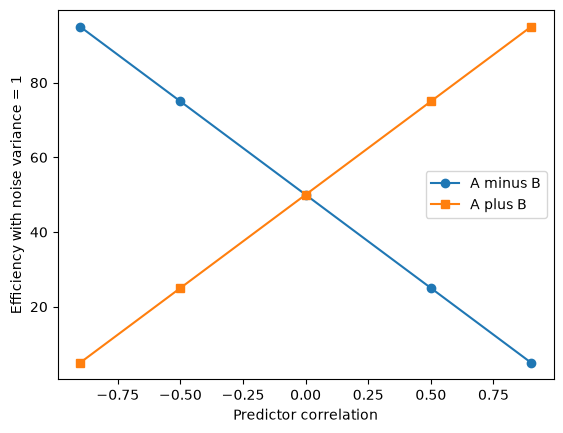

At correlation 1, the difference can vary without changing fitted data.


In [2]:
plt.plot(rhos, 1 / variances[:, 0], 'o-', label='A minus B')
plt.plot(rhos, 1 / variances[:, 1], 's-', label='A plus B')
plt.xlabel('Predictor correlation'); plt.ylabel('Efficiency with noise variance = 1')
plt.legend(); plt.show()
X_bad = np.column_stack([np.ones(n), u, u])
assert np.linalg.matrix_rank(X_bad) == 2
assert np.allclose(X_bad @ [0, 1, -1], 0)
print('At correlation 1, the difference can vary without changing fitted data.')

## Supervise the AI, then transfer the idea

**AI prompt:** “Explain why the two efficiency curves move in opposite directions. Name c, X, and the noise assumption. Before suggesting better timing, ask which contrast matters. Give at most 15 lines comparing designs after including a drift column, preserving predictor units.”

**Deliberate mistake:** remove B because it correlates with A, then interpret the remaining A coefficient as the original adjusted effect. State what model and estimand changed. For transfer, retain task-duration constraints, nuisance specification, high-pass filtering, and temporal covariance in the comparison. Simulate plausible HRF variation and task failures rather than optimizing one ideal waveform. Deliver a two-contrast efficiency table and explain which design you would choose for each scientific aim; a single design ranking without a contrast is incomplete.

## Answer key — read after your own explanation

At n=100 and rho=.9, difference variance is .2 and sum variance is about .01053 under unit iid noise. Reversing rho reverses their advantages. Perfectly identical condition predictors make A-minus-B non-estimable. Efficiency changes under arbitrary predictor rescaling, so units and contrast scaling must be fixed. Lower multicollinearity does not by itself justify dropping an experimental event or a necessary confound.

## Source trail

Original explanations and synthetic experiments; these are parallel learning materials, not an official USC syllabus. [Poldrack EfficiencyCorrelation, pinned notebook](https://github.com/poldrack/fmri-analysis-vm/blob/d93fcf8e818c850d0a1b4e96b01ac987f27e9d34/analysis/efficiency/EfficiencyCorrelation.ipynb); [Poldrack DesignEfficiency](https://github.com/poldrack/fmri-analysis-vm/blob/d93fcf8e818c850d0a1b4e96b01ac987f27e9d34/analysis/efficiency/DesignEfficiency.ipynb). See [the coverage and gaps](../../curriculum/design_coverage.md).

### Return to the research question

Reopen [PD06](../../curriculum/papers/design.md#pd06), [PD01](../../curriculum/papers/design.md#pd01) and your initial two-sentence prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure/section locator. State what this small exercise still cannot establish about the published result.
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Reuse this entry in the A2 portfolio when relevant; a separate report is unnecessary.
